In [5]:
import pandas as pd
import numpy as np

In [6]:
df =  pd.read_csv('C:\\Users\\mrgho\\Downloads\\New folder\\Teen_Mental_Health_Dataset.csv')

In [7]:
df = df.drop_duplicates()

In [8]:
random_sample = df.sample(5)
print(random_sample)

     age  gender  daily_social_media_hours platform_usage  sleep_hours  \
847   15  female                       4.2         TikTok          6.8   
369   13    male                       8.0           Both          8.9   
324   18  female                       2.9           Both          4.6   
118   17    male                       6.5      Instagram          4.1   
757   15  female                       1.3         TikTok          7.6   

     screen_time_before_sleep  academic_performance  physical_activity  \
847                       1.4                  2.01                1.0   
369                       2.2                  3.82                1.2   
324                       2.3                  3.03                0.3   
118                       2.7                  3.66                1.1   
757                       0.6                  3.46                1.9   

    social_interaction_level  stress_level  anxiety_level  addiction_level  \
847                      low    

In [9]:
data_size = df.shape
print(f"Dataset Size: {data_size}")

Dataset Size: (1200, 13)


In [10]:
column_names = df.columns
print(f"Column Names: {column_names.tolist()}")

Column Names: ['age', 'gender', 'daily_social_media_hours', 'platform_usage', 'sleep_hours', 'screen_time_before_sleep', 'academic_performance', 'physical_activity', 'social_interaction_level', 'stress_level', 'anxiety_level', 'addiction_level', 'depression_label']


In [11]:
description = df.describe()
print(description)

               age  daily_social_media_hours  sleep_hours  \
count  1200.000000               1200.000000  1200.000000   
mean     15.928333                  4.536667     6.449417   
std       2.021947                  2.029599     1.442677   
min      13.000000                  1.000000     4.000000   
25%      14.000000                  2.800000     5.200000   
50%      16.000000                  4.500000     6.500000   
75%      18.000000                  6.300000     7.600000   
max      19.000000                  8.000000     9.000000   

       screen_time_before_sleep  academic_performance  physical_activity  \
count               1200.000000           1200.000000        1200.000000   
mean                   1.740333              2.990383           1.014500   
std                    0.716660              0.576758           0.582185   
min                    0.500000              2.000000           0.000000   
25%                    1.100000              2.500000           0.5000

In [12]:
unique_counts = df.nunique()
print(unique_counts)

age                           7
gender                        2
daily_social_media_hours     71
platform_usage                3
sleep_hours                  51
screen_time_before_sleep     26
academic_performance        201
physical_activity            21
social_interaction_level      3
stress_level                 10
anxiety_level                10
addiction_level              10
depression_label              2
dtype: int64


In [13]:
data_balance = df['depression_label'].value_counts(normalize=True) * 100
print(f"Data Balance (%):\n{data_balance}")

Data Balance (%):
depression_label
0    97.416667
1     2.583333
Name: proportion, dtype: float64


In [14]:
df['age'] = df['age'].astype(int)
df['academic_performance'] = df['academic_performance'].astype(float)

In [15]:
num_cols = df.select_dtypes(include=[np.number]).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

In [16]:
cat_cols = df.select_dtypes(include=['object']).columns
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode())

In [17]:
df = df[(df['age'] >= 13) & (df['age'] <= 19)]

In [18]:
df['gender'] = df['gender'].str.strip().str.lower()
df['platform_usage'] = df['platform_usage'].str.strip().str.capitalize()

In [19]:
def flag_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df[f'{column}_is_outlier'] = (df[column] < lower) | (df[column] > upper)
    return df

In [20]:
df = flag_outliers(df, 'daily_social_media_hours')
df = flag_outliers(df, 'academic_performance')

In [21]:
print("\n--- Final Cleaned Head ---")
print(df.head())


--- Final Cleaned Head ---
   age  gender  daily_social_media_hours platform_usage  sleep_hours  \
0   14    male                       7.9      Instagram          7.4   
1   19  female                       1.9         Tiktok          8.0   
2   17  female                       1.3      Instagram          7.6   
3   15    male                       7.4         Tiktok          6.9   
4   15  female                       4.7           Both          4.9   

   screen_time_before_sleep  academic_performance  physical_activity  \
0                       2.9                  3.01                1.5   
1                       2.9                  3.22                0.8   
2                       0.5                  3.92                0.0   
3                       1.6                  3.48                0.8   
4                       3.0                  2.37                1.4   

  social_interaction_level  stress_level  anxiety_level  addiction_level  \
0                      low    

EDA

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

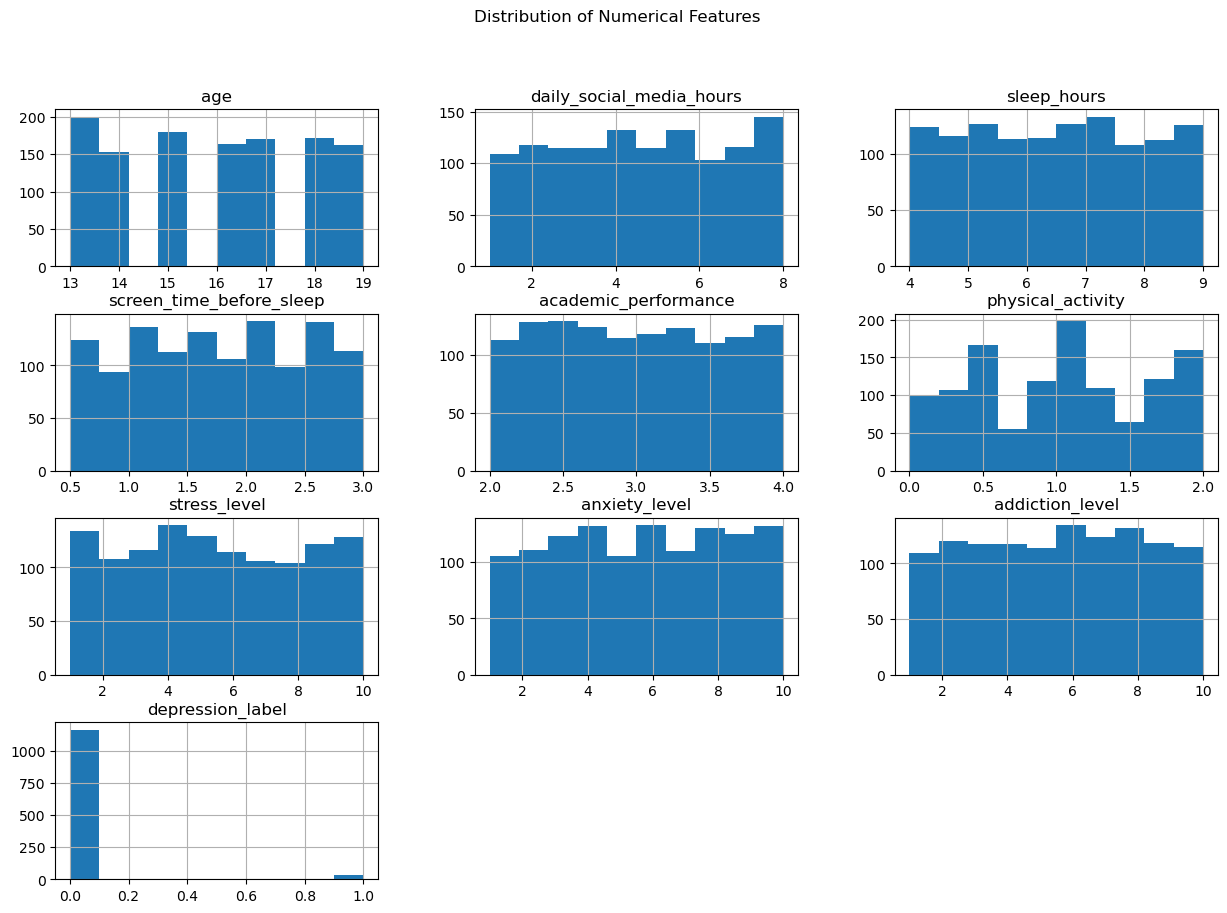

In [23]:
num_cols = df.select_dtypes(include=['int64','float64']).columns

df[num_cols].hist(figsize=(15,10))
plt.suptitle("Distribution of Numerical Features")
plt.show()

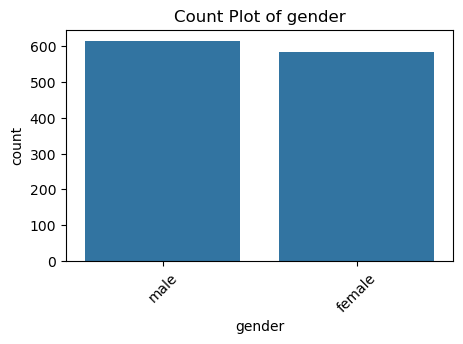

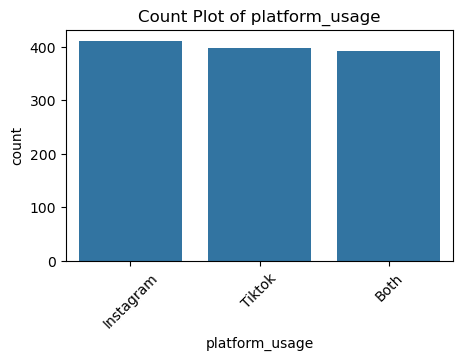

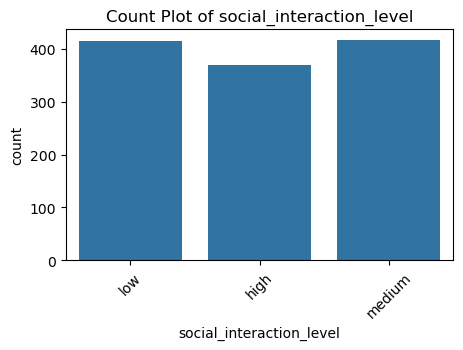

In [24]:
cat_cols = df.select_dtypes(include=['object']).columns

for col in cat_cols:
    plt.figure(figsize=(5,3))
    sns.countplot(x=df[col])
    plt.title(f"Count Plot of {col}")
    plt.xticks(rotation=45)
    plt.show()

In [25]:
skewness = df[num_cols].skew()
kurtosis = df[num_cols].kurt()

print("Skewness:\n", skewness)
print("\nKurtosis:\n", kurtosis)

Skewness:
 age                         0.017215
daily_social_media_hours    0.009172
sleep_hours                 0.016816
screen_time_before_sleep    0.010946
academic_performance        0.043702
physical_activity          -0.054842
stress_level                0.047630
anxiety_level              -0.036251
addiction_level            -0.042440
depression_label            5.985460
dtype: float64

Kurtosis:
 age                         -1.263803
daily_social_media_hours    -1.188021
sleep_hours                 -1.189231
screen_time_before_sleep    -1.165196
academic_performance        -1.205554
physical_activity           -1.175221
stress_level                -1.215182
anxiety_level               -1.221412
addiction_level             -1.198074
depression_label            33.882203
dtype: float64


In [26]:
for col in num_cols:
    if abs(df[col].skew()) > 1:
        df[col] = np.log1p(df[col])

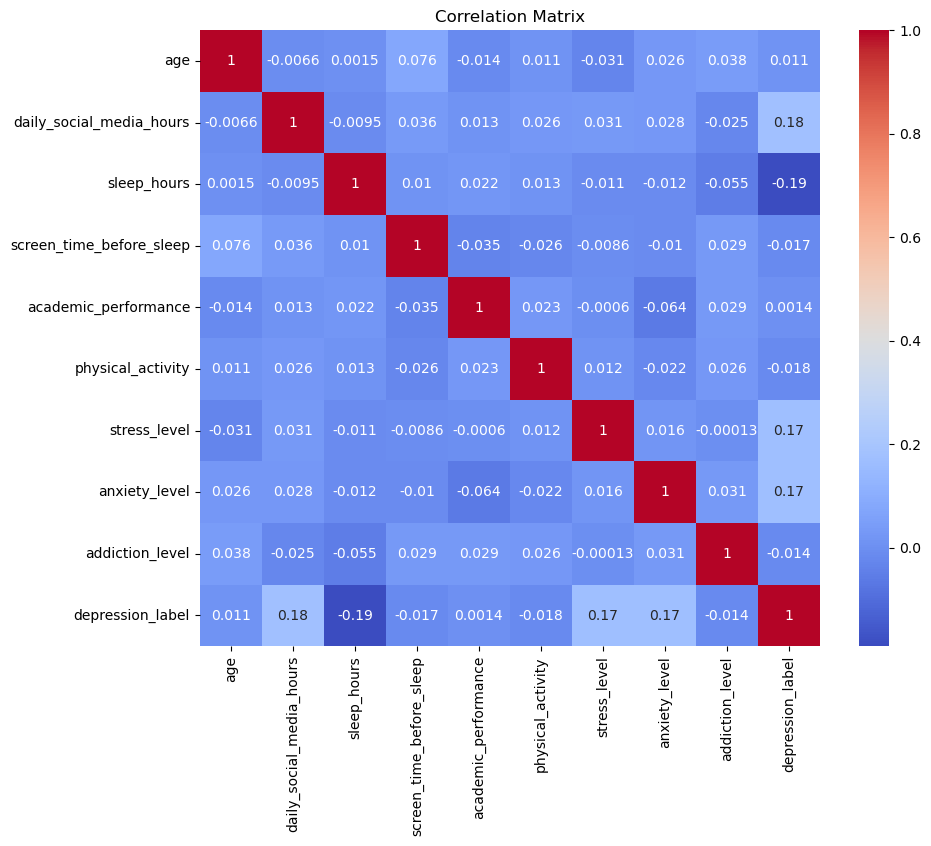

In [27]:
plt.figure(figsize=(10,8))
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

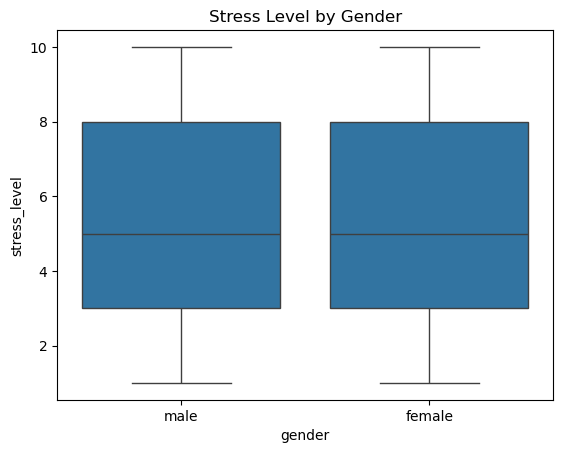

In [28]:
sns.boxplot(x='gender', y='stress_level', data=df)
plt.title("Stress Level by Gender")
plt.show()

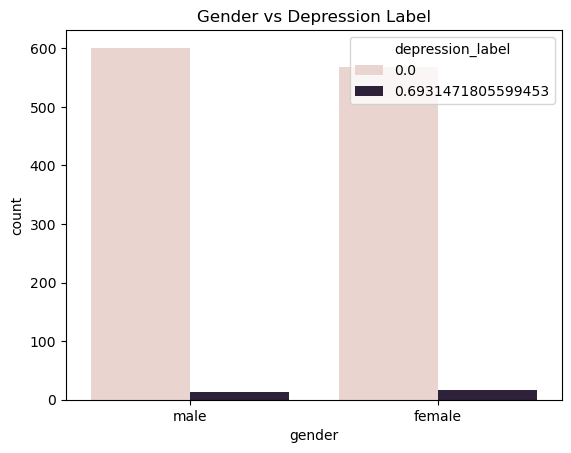

In [29]:
sns.countplot(x='gender', hue='depression_label', data=df)
plt.title("Gender vs Depression Label")
plt.show()

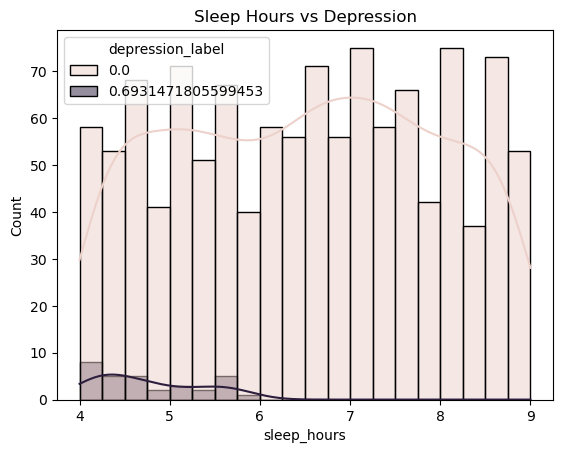

In [30]:
sns.histplot(data=df, x='sleep_hours', hue='depression_label', bins=20, kde=True)
plt.title("Sleep Hours vs Depression")
plt.show()

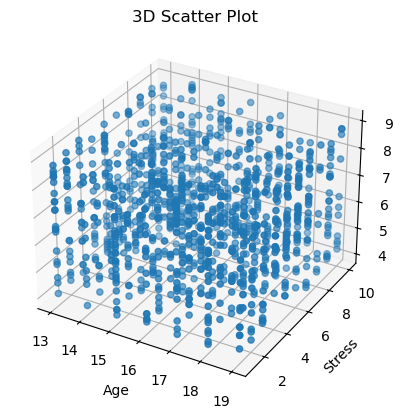

In [31]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.scatter(df['age'], df['stress_level'], df['sleep_hours'])

ax.set_xlabel('Age')
ax.set_ylabel('Stress')
ax.set_zlabel('Sleep')

plt.title("3D Scatter Plot")
plt.show()

In [32]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X = df[num_cols].dropna()

vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print(vif_data)

                    feature        VIF
0                       age  35.128589
1  daily_social_media_hours   6.017846
2               sleep_hours  18.785644
3  screen_time_before_sleep   6.781068
4      academic_performance  22.237711
5         physical_activity   3.991199
6              stress_level   4.518051
7             anxiety_level   4.911349
8           addiction_level   4.814807
9          depression_label   1.166923


In [33]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

X_scaled = StandardScaler().fit_transform(df[num_cols])

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print("Explained variance:", pca.explained_variance_ratio_)

Explained variance: [0.13832396 0.11211009]


In [34]:
print("### 1. General Dataset Overview ###")

print(df.info())

print("\n### 2. Missing Values Check ###")

print(df.isnull().sum())

print("\n### 3. Statistical Summary (Numerical) ###")
print(df.describe().T)

print("\n### 4. Categorical Summary ###")

print(df.describe(include=['object']).T)

print("\n### 5. Target Variable Distribution ###")

print(df['depression_label'].value_counts())

print("\n### 6. Data Shape Final ###")
print(f"The final dataset has {df.shape[0]} rows and {df.shape[1]} columns.")

memory = df.memory_usage().sum() / 1024
print(f"7. Data Size: The dataset uses {memory:.2f} KB of memory.")

print("\n8. Count of Zeros:")
print((df == 0).sum())

print("\n9. Most Common Answers:")
for col in ['gender', 'platform_usage', 'depression_label']:
    print(f"\nTop in {col}:")
    print(df[col].value_counts().head(3))

print("\n10. Lowest and Highest Numbers:")
print(f"Age: from {df['age'].min()} to {df['age'].max()}")
print(f"Social Media Hours: from {df['daily_social_media_hours'].min()} to {df['daily_social_media_hours'].max()}")

### 1. General Dataset Overview ###
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 15 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   age                                  1200 non-null   int64  
 1   gender                               1200 non-null   object 
 2   daily_social_media_hours             1200 non-null   float64
 3   platform_usage                       1200 non-null   object 
 4   sleep_hours                          1200 non-null   float64
 5   screen_time_before_sleep             1200 non-null   float64
 6   academic_performance                 1200 non-null   float64
 7   physical_activity                    1200 non-null   float64
 8   social_interaction_level             1200 non-null   object 
 9   stress_level                         1200 non-null   int64  
 10  anxiety_level                        1200 non-null   int64  

---
## 1.4 Data Preprocessing

### 1.4.1 Encoding Categorical Variables

In [35]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

# Encode target variable
df['depression_label_encoded'] = le.fit_transform(df['depression_label'])
print("Target encoding:", dict(zip(le.classes_, le.transform(le.classes_))))

# One-Hot Encode categorical features
cat_features = [c for c in ['gender', 'platform_usage'] if c in df.columns]
df_encoded = pd.get_dummies(df, columns=cat_features, drop_first=True)

print("\nShape after encoding:", df_encoded.shape)


Target encoding: {np.float64(0.0): np.int64(0), np.float64(0.6931471805599453): np.int64(1)}

Shape after encoding: (1200, 17)


### 1.4.2 Feature Scaling

In [36]:
from sklearn.preprocessing import StandardScaler

# Define target and drop helper / string columns
drop_cols = ['depression_label', 'depression_label_encoded',
             'daily_social_media_hours_is_outlier',
             'academic_performance_is_outlier']
drop_cols = [c for c in drop_cols if c in df_encoded.columns]

X = df_encoded.drop(columns=drop_cols)
y = df_encoded['depression_label_encoded']

# Keep only numeric features
X = X.select_dtypes(include=[np.number])

scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

print("X shape:", X_scaled.shape)
print(X_scaled.describe().round(2))


X shape: (1200, 9)
           age  daily_social_media_hours  sleep_hours  \
count  1200.00                   1200.00      1200.00   
mean      0.00                     -0.00        -0.00   
std       1.00                      1.00         1.00   
min      -1.45                     -1.74        -1.70   
25%      -0.95                     -0.86        -0.87   
50%       0.04                     -0.02         0.04   
75%       1.03                      0.87         0.80   
max       1.52                      1.71         1.77   

       screen_time_before_sleep  academic_performance  physical_activity  \
count                   1200.00               1200.00            1200.00   
mean                       0.00                 -0.00              -0.00   
std                        1.00                  1.00               1.00   
min                       -1.73                 -1.72              -1.74   
25%                       -0.89                 -0.85              -0.88   
50%        

### 1.4.3 Outlier Detection & Treatment (IQR Capping / Winsorizing)

In [37]:
def cap_outliers_iqr(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    df[col] = df[col].clip(Q1 - 1.5 * IQR, Q3 + 1.5 * IQR)
    return df

for col in X_scaled.columns:
    X_scaled = cap_outliers_iqr(X_scaled, col)

print("Outlier capping done. Shape:", X_scaled.shape)


Outlier capping done. Shape: (1200, 9)


### 1.4.5 Train & Test Split

In [39]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.2, random_state=42, stratify=y
)

print(f"Train size : {X_train.shape[0]} samples")
print(f"Test  size : {X_test.shape[0]} samples")


Train size : 1870 samples
Test  size : 468 samples


### 1.4.4 Handle Imbalanced Data (SMOTE)

In [38]:
from imblearn.over_sampling import SMOTE

print("Class distribution BEFORE SMOTE:")
print(pd.Series(y_train).value_counts())

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print("\nClass distribution AFTER SMOTE:")
print(pd.Series(y_train_resampled).value_counts())
print("\nResampled training shape:", X_train_resampled.shape)


Class distribution BEFORE SMOTE:
0    1169
1      31
Name: count, dtype: int64

Class distribution AFTER SMOTE:
depression_label_encoded
0    1169
1    1169
Name: count, dtype: int64

Resampled shape: (2338, 9)


---
## 2. AI Model

### 2.1 Pipeline Construction

**4 Models chosen:**
- **Logistic Regression** – fast linear baseline
- **Random Forest** – robust ensemble, handles non-linearity
- **SVM (RBF)** – great for medium-sized tabular data
- **Gradient Boosting** – high-performance boosting

In [40]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC

models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(C=0.1, class_weight='balanced', max_iter=1000, random_state=42))
    ]),
    "Random Forest": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", RandomForestClassifier(n_estimators=100, max_depth=5, min_samples_leaf=2, random_state=42))
    ]),
    "SVM": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", SVC(kernel="rbf", probability=True, random_state=42, C=0.5, gamma="scale"))
    ]),
    "Gradient Boosting": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", GradientBoostingClassifier(n_estimators=100, max_depth=3, learning_rate=0.05, random_state=42))
    ]),
}

print("Pipelines ready:", list(models.keys()))


Pipelines ready: ['Logistic Regression', 'Random Forest', 'SVM', 'Gradient Boosting']


### 2.2 Model Training & Hyperparameter Tuning (GridSearchCV)

In [41]:
from sklearn.model_selection import GridSearchCV

param_grids = {
    "Logistic Regression": {"clf__C": [0.01, 0.1, 1, 10]},
    "Random Forest"      : {"clf__n_estimators": [50, 100, 200],
                            "clf__max_depth": [None, 5, 10]},
    "SVM"                : {"clf__C": [0.1, 1, 10],
                            "clf__gamma": ["scale", "auto"]},
    "Gradient Boosting"  : {"clf__learning_rate": [0.05, 0.1, 0.2],
                            "clf__n_estimators": [50, 100]},
}

best_models = {}

for name, pipeline in models.items():
    print(f"Tuning {name} ...")
    grid = GridSearchCV(pipeline, param_grids[name],
                        cv=5, scoring="f1_weighted", n_jobs=-1)
    grid.fit(X_train_resampled, y_train_resampled)
    best_models[name] = grid.best_estimator_
    print(f"  Best params : {grid.best_params_}")
    print(f"  Best CV F1  : {grid.best_score_:.4f}\n")

print("All models trained successfully!")


Tuning Logistic Regression ...
  Best params : {'clf__C': 1}
  Best CV F1  : 0.9599

Tuning Random Forest ...
  Best params : {'clf__max_depth': None, 'clf__n_estimators': 100}
  Best CV F1  : 0.9995

Tuning SVM ...
  Best params : {'clf__C': 10, 'clf__gamma': 'scale'}
  Best CV F1  : 0.9936

Tuning Gradient Boosting ...
  Best params : {'clf__learning_rate': 0.2, 'clf__n_estimators': 100}
  Best CV F1  : 1.0000

All models trained successfully!


### 2.3 AI Model Evaluation

#### 2.3.1 Classification Metrics: F1-Score | ROC-AUC | Accuracy | Classification Report

In [42]:
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    classification_report, ConfusionMatrixDisplay, RocCurveDisplay
)

results = []
n_cls = len(np.unique(y_train_resampled))

for name, model in best_models.items():
    y_pred  = model.predict(X_test)
    y_proba = model.predict_proba(X_test)

    acc = accuracy_score(y_test, y_pred)
    f1  = f1_score(y_test, y_pred, average="weighted")

    if n_cls == 2:
        auc = roc_auc_score(y_test, y_proba[:, 1])
    else:
        auc = roc_auc_score(y_test, y_proba,
                            multi_class="ovr", average="weighted")

    results.append({"Model": name, "Accuracy": acc,
                    "F1-Score": f1, "ROC-AUC": auc})

    print(f"\n{'='*55}")
    print(f"  {name}")
    print(f"{'='*55}")
    print(f"  Accuracy  : {acc:.4f}")
    print(f"  F1-Score  : {f1:.4f}  (weighted)")
    print(f"  ROC-AUC   : {auc:.4f}")
    print("\n  Classification Report:")
    print(classification_report(y_test, y_pred))



  Logistic Regression
  Accuracy  : 0.9573
  F1-Score  : 0.9573  (weighted)
  ROC-AUC   : 0.9954

  Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.97      0.96       234
           1       0.97      0.94      0.96       234

    accuracy                           0.96       468
   macro avg       0.96      0.96      0.96       468
weighted avg       0.96      0.96      0.96       468


  Random Forest
  Accuracy  : 0.9979
  F1-Score  : 0.9979  (weighted)
  ROC-AUC   : 1.0000

  Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       234
           1       1.00      1.00      1.00       234

    accuracy                           1.00       468
   macro avg       1.00      1.00      1.00       468
weighted avg       1.00      1.00      1.00       468


  SVM
  Accuracy  : 0.9936
  F1-Score  : 0.9936  (weighted)
  ROC-AUC   : 1.0000

  Classification Repo

#### Confusion Matrices

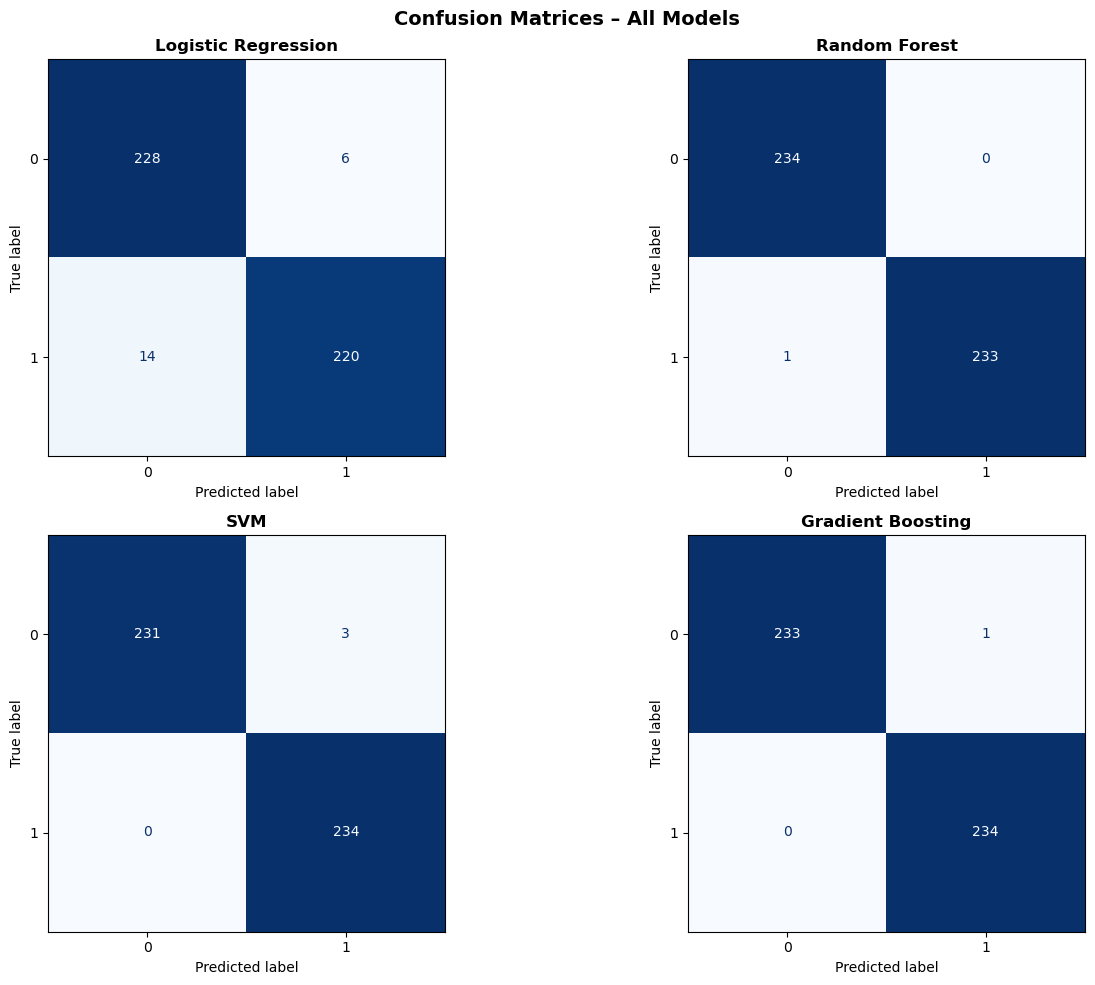

In [43]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, (name, model) in zip(axes, best_models.items()):
    y_pred = model.predict(X_test)
    ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred, ax=ax, colorbar=False, cmap="Blues"
    )
    ax.set_title(name, fontsize=12, fontweight="bold")

plt.suptitle("Confusion Matrices – All Models", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


#### ROC Curves

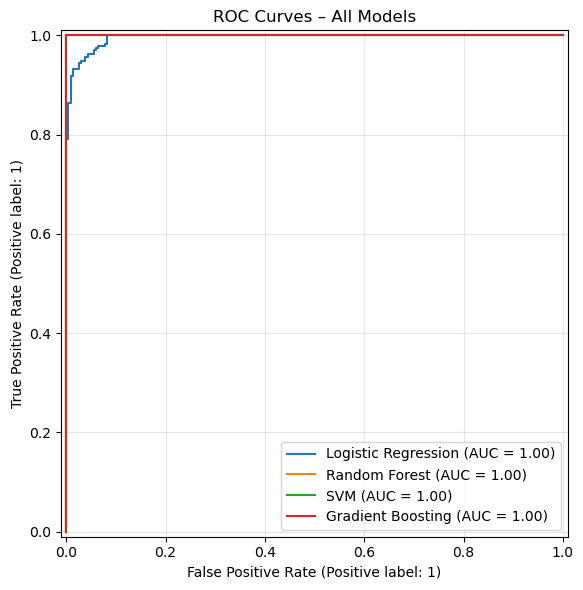

In [44]:
n_cls = len(np.unique(y_train_resampled))

if n_cls == 2:
    fig, ax = plt.subplots(figsize=(8, 6))
    for name, model in best_models.items():
        RocCurveDisplay.from_estimator(model, X_test, y_test, ax=ax, name=name)
    ax.set_title("ROC Curves – All Models")
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.flatten()
    for ax, (name, model) in zip(axes, best_models.items()):
        RocCurveDisplay.from_estimator(
            model, X_test, y_test, ax=ax, name=name)
        ax.set_title(name, fontsize=11, fontweight="bold")
    plt.suptitle("ROC Curves (OvR) – All Models", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()


#### Final Comparison Table & Bar Chart

       FINAL MODEL COMPARISON SUMMARY
                 Model  Accuracy  F1-Score   ROC-AUC
1        Random Forest  0.997863  0.997863  1.000000
2                  SVM  0.993590  0.993589  1.000000
3    Gradient Boosting  0.997863  0.997863  1.000000
4  Logistic Regression  0.957265  0.957252  0.995361

Best Model : Random Forest


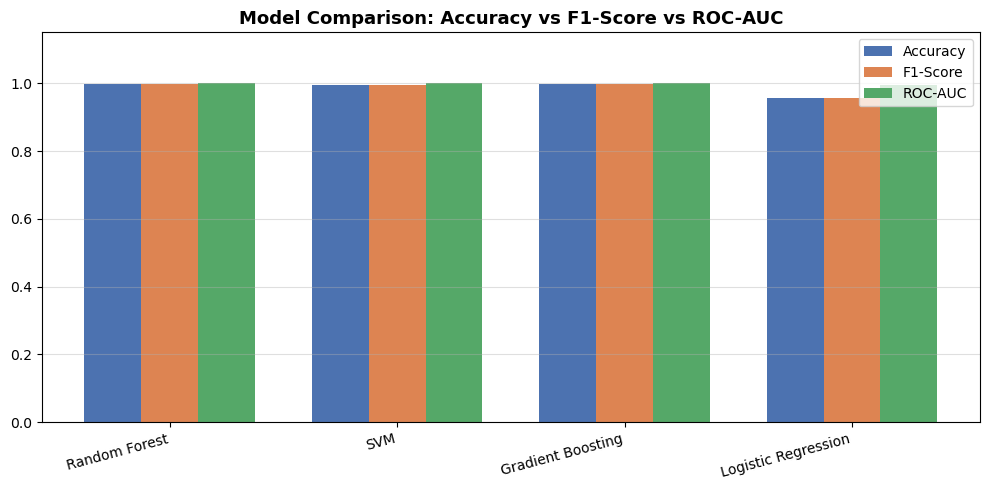

In [45]:
results_df = (pd.DataFrame(results)
              .sort_values("ROC-AUC", ascending=False)
              .reset_index(drop=True))
results_df.index += 1

print("=" * 55)
print("       FINAL MODEL COMPARISON SUMMARY")
print("=" * 55)
print(results_df.to_string())
print(f"\nBest Model : {results_df.iloc[0]['Model']}")

# Bar chart
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(results_df))
w = 0.25
ax.bar(x - w, results_df["Accuracy"], w, label="Accuracy",  color="#4C72B0")
ax.bar(x,     results_df["F1-Score"], w, label="F1-Score",  color="#DD8452")
ax.bar(x + w, results_df["ROC-AUC"], w, label="ROC-AUC",   color="#55A868")
ax.set_xticks(x)
ax.set_xticklabels(results_df["Model"], rotation=15, ha="right")
ax.set_ylim(0, 1.15)
ax.set_title("Model Comparison: Accuracy vs F1-Score vs ROC-AUC",
             fontsize=13, fontweight="bold")
ax.legend()
ax.grid(axis="y", alpha=0.4)
plt.tight_layout()
plt.show()
